# Libraries

In [138]:
import numpy as np
import scipy
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math

root = str(Path().resolve().parent)
if root not in sys.path:
    sys.path.append(root)
print(*sys.path, sep="\n")

%matplotlib ipympl
# %matplotlib inline

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/home/ryanwtsai/repos/rfdsp_sim/python/venv/lib/python3.12/site-packages
/home/ryanwtsai/repos/rfdsp_sim/python


In [90]:
from importlib import reload
from rfdsppy import calc, ofdm, rf_analog, rf_tx_fw, tonegen, digital_filter_design, digital_hw_algo as dighw, rf_estimation as rf_est

reload(calc)
reload(ofdm)
reload(rf_analog)
reload(rf_tx_fw)
reload(tonegen)
reload(digital_filter_design)
reload(dighw)
reload(rf_est)

<module 'rfdsppy.rf_estimation' from '/home/ryanwtsai/repos/rfdsp_sim/python/rfdsppy/rf_estimation.py'>

# VSA DSP

digital_filter_design.firls_rate_change()
Largest passband ripple (dB) = 0.0
Smallest stopband rejection (dB) = 157.3



digital_filter_design.firls_rate_change()
Largest passband ripple (dB) = 0.0
Smallest stopband rejection (dB) = 175.6



digital_filter_design.firls_rate_change()
Largest passband ripple (dB) = 0.0
Smallest stopband rejection (dB) = 172.9



digital_filter_design.firls_rate_change()
Largest passband ripple (dB) = 0.0
Smallest stopband rejection (dB) = 113.2





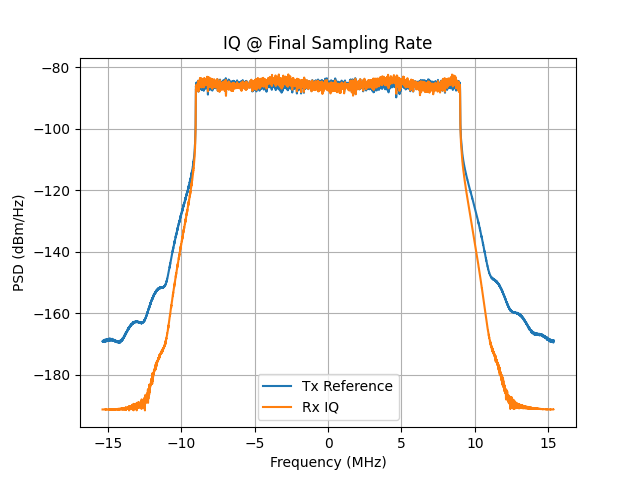

In [172]:
bw = 20
scs = 15
modorder = 4
start_sc = 0
num_sc = 1200

# Generate baseband waveform
wg = ofdm.OFDMWavGen(bw, scs, modorder, start_sc, num_sc, osr=1, power=0)

x_bb, x_standard = wg.generate(14)
cfg = wg.get_demod_params()
fs_bb = cfg.get("fs")
obw = num_sc*scs/1000
# p_bb, f_bb = rf_est.sde(x_bb, fs_bb, fs_bb/4096)

# Convert to analog signal (upsample)
b = digital_filter_design.firls_rate_change("up", 33, obw, fs_bb*2, 2)
x = dighw.upsample(x_bb, 2)
x = signal.lfilter(b*2/b.sum(), 1, x)

b = digital_filter_design.firls_rate_change("up", 33, obw, fs_bb*4, 2)
x = dighw.upsample(x, 2)
x = signal.lfilter(b*2/b.sum(), 1, x)

b = digital_filter_design.firls_rate_change("up", 33, obw, fs_bb*8, 2)
x = dighw.upsample(x, 2)
x = signal.lfilter(b*2/b.sum(), 1, x)

# Analog and ADC sampling rates
fs_analog = fs_bb*8
fs_min = num_sc*scs/1000*2 # 36 MHz
fs_adc = 61.44 # ADC sampling rate

# Analog IF signal
x_if = (np.exp(1j*(5/4*fs_adc/fs_analog)*2*np.pi*np.arange(x.size, dtype="float"))*x).real

# Simulate some channel frequency response
wp = [1.25*fs_adc-num_sc*scs/1000/2, 1.25*fs_adc+num_sc*scs/1000/2]
ws = [wp[0]*0.8, wp[1]*1.2]
gpass = 2
gstop = 50
b_if, a_if = signal.iirdesign(wp, ws, gpass, gstop, ftype="ellip", fs=fs_analog)

x_if = signal.lfilter(b_if, a_if, x_if)

# Add a blocker
bg = ofdm.OFDMWavGen(20, 15, 4, 600-6, 12, osr=8, power=20)
blocker, _ = bg.generate(14)
blocker = (np.exp(1j*(3/4*fs_adc/fs_analog)*2*np.pi*np.arange(blocker.size, dtype="float"))*blocker).real[:x_if.size]
# x_if = x_if+blocker
p, f = rf_est.sde(x_if, fs_analog, fs_analog/4096)

# fig, ax = plt.subplots(dpi=100)
# ax.plot(f, 10*np.log10(p))
# ax.set_title("Final Analog IF")
# ax.set_xlabel("Frequency (MHz)")
# ax.set_ylabel("PSD (dBm/Hz)")
# ax.vlines(fs_adc/2*np.arange(5, dtype="float"), ymin=-240, ymax=10*np.log10(p.max()), colors='r')
# ax.grid()

# ADC
x_adc = x_if[::round(fs_analog/fs_adc)]
p, f = rf_est.sde(x_adc, fs_adc, fs_adc/4096)

# fig, ax = plt.subplots(dpi=100)
# ax.plot(f, 10*np.log10(p))
# ax.set_title("ADC Output")
# ax.set_xlabel("Frequency (MHz)")
# ax.set_ylabel("PSD (dBm/Hz)")
# ax.grid()

# DDC
x_ddc = np.exp(-1j*(fs_adc/4/fs_adc)*2*np.pi*np.arange(x_adc.size, dtype="float"))*x_adc
p, f = rf_est.sde(x_ddc, fs_adc, fs_adc/4096)

# fig, ax = plt.subplots(dpi=100)
# ax.plot(f, 10*np.log10(p))
# ax.set_title("IQ Post-DDC")
# ax.set_xlabel("Frequency (MHz)")
# ax.set_ylabel("PSD (dBm/Hz)")
# ax.grid()

# AAF
b = digital_filter_design.firls_rate_change("down", 33, num_sc*scs/1000, fs_adc, 2)
x_aaf = signal.lfilter(b, 1, x_ddc)
p, f = rf_est.sde(x_aaf, fs_adc, fs_adc/4096)

# fig, ax = plt.subplots(dpi=100)
# ax.plot(f, 10*np.log10(p))
# ax.set_title("IQ Post-AAF")
# ax.set_xlabel("Frequency (MHz)")
# ax.set_ylabel("PSD (dBm/Hz)")
# ax.grid()

# Downsample by 2
x_down = x_aaf[::2]
fs_iq = fs_adc/2
# p, f = rf_est.sde(x_down, fs_iq, fs_iq/4096)

# Timing alignment and gain equalization
x_bb1, x_down1 = rf_est.time_align(x_bb, x_down)
# g = rf_est.est_single_tap_channel(x_bb1, x_down1)
x_down1 = rf_est.comp_single_tap_channel(x_bb1, x_down1)

fig, ax = plt.subplots(dpi=100)
p, f = rf_est.sde(x_bb1, fs_iq, fs_iq/4096)
ax.plot(f, 10*np.log10(p), label="Tx Reference")
p, f = rf_est.sde(x_down1, fs_iq, fs_iq/4096)
ax.plot(f, 10*np.log10(p), label="Rx IQ")
ax.set_title("IQ @ Final Sampling Rate")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("PSD (dBm/Hz)")
ax.legend(loc="lower center")
ax.grid()

# _ = rf_est.sde(x, fs_analog, fs_analog/4096, en_plot=True)
# _ = rf_est.sde(x_if, fs_analog, fs_analog/4096, en_plot=True, title="Final Analog IF")
# _ = rf_est.sde(x_adc, fs_adc, fs_adc/4096, en_plot=True, title="ADC Output")

In [167]:
# Which bins will be occupied?

N = 4096

binsize = fs_iq/N
nbins = round(obw/2/binsize)

In [152]:
x_bb1[4096:4096*2].size

4096

In [163]:
# Channel estimation

h_fft = np.zeros(N, dtype="complex")
for idx in range(6):
    x_fft = scipy.fft.fft(x_bb1[(idx+1)*N:(idx+2)*N])
    y_fft = scipy.fft.fft(x_down1[(idx+1)*N:(idx+2)*N])
    h_fft = h_fft + y_fft/x_fft

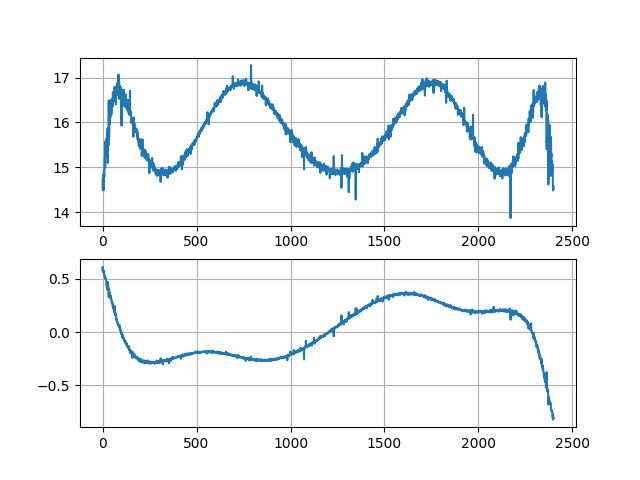

In [171]:
fig, axs = plt.subplots(nrows=2, ncols=1, dpi=100)

h_fft_sig = np.concatenate((h_fft[h_fft.size-nbins:], h_fft[:nbins]))
axs[0].plot(20*np.log10(np.abs(h_fft_sig)))
axs[1].plot(np.angle(h_fft_sig))
axs[0].grid()
axs[1].grid()

(-3.0, 1.0)

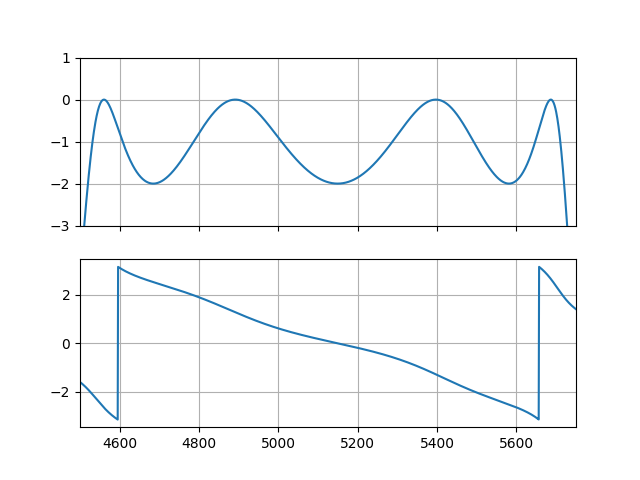

In [177]:
w, h_if = signal.freqz(b_if, a_if, 4096*2)

fig, axs = plt.subplots(nrows=2, ncols=1, dpi=100, sharex=True)

axs[0].plot(20*np.log10(np.abs(h_if)))
axs[1].plot(np.angle(h_if))
axs[0].grid()
axs[1].grid()
axs[0].set_xlim(left=4500, right=5750)
axs[0].set_ylim(bottom=-3, top=1)

0.223606797749979
0.23169121884603824


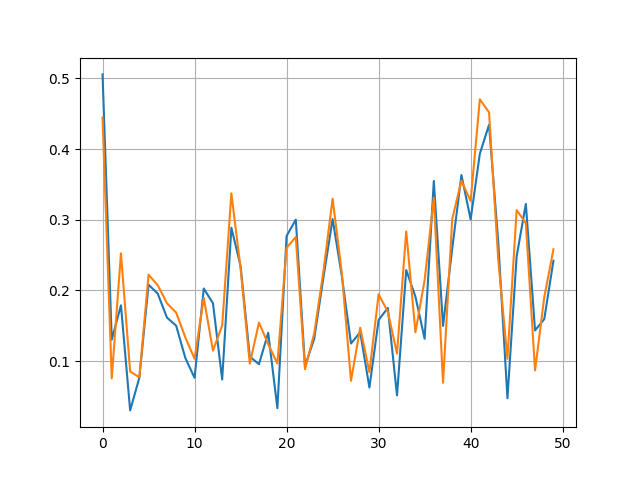

In [145]:
# x_bb1, x_down1 = rf_est.time_align(x_bb, x_down)
# # g = rf_est.est_single_tap_channel(x_bb1, x_down1)
# x_down2 = rf_est.comp_single_tap_channel(x_bb1, x_down1)
print(calc.rms(x_bb1))
print(calc.rms(x_down1))
(np.abs(x_bb1[:x_down1.size] - x_down1)**2).sum()/(np.abs(x_bb1[:x_down1.size])**2).sum()
# print(calc.rms(x_down2))

fig, ax = plt.subplots(dpi=100)
ax.plot(np.abs(x_bb1[4096:4096+50]))
ax.plot(np.abs(x_down1[4096:4096+50]))
ax.grid()

/home/ryanwtsai/repos/rfdsp_sim/python/venv/lib/python3.12/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


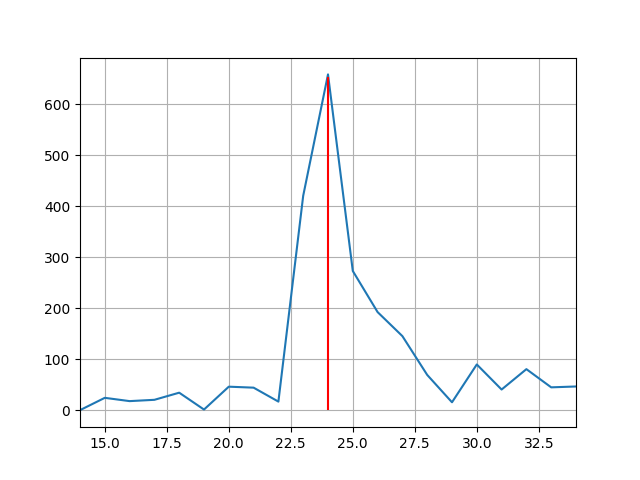

In [146]:
corr = signal.correlate(x_down, x_bb)
lags = signal.correlation_lags(x_down.size, x_bb.size)

delay = lags[corr.argmax()]

fig, ax = plt.subplots(dpi=100)
ax.plot(lags, np.abs(corr))
ax.vlines([delay], ymin=0, ymax=corr.max(), colors='r')
ax.set_xlim(left=delay-10, right=delay+10)
ax.grid()


Filter order = 9
Maximum passband loss (dB) = 2.0
Minimum stopband attenuation (dB) = 50.0


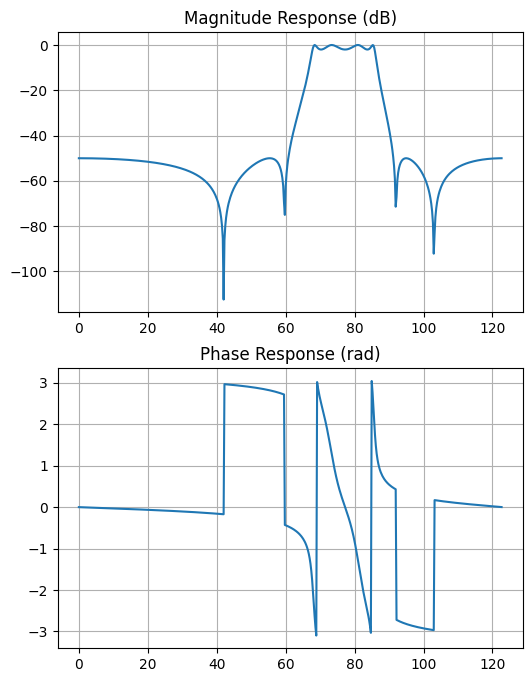

In [48]:
wp = [1.25*fs_adc-num_sc*scs/1000/2, 1.25*fs_adc+num_sc*scs/1000/2]
ws = [wp[0]*0.8, wp[1]*1.2]
gpass = 2
gstop = 50
b, a = signal.iirdesign(wp, ws, gpass, gstop, ftype="ellip", fs=fs_analog)
w, h = signal.freqz(b, a, fs=fs_analog)

h_pb = 20*np.log10(np.abs(h[np.logical_and(w <= wp[1], w >= wp[0])]))
h_sb = -20*np.log10(np.abs(h[np.logical_or(w >= ws[1], w <= ws[0])]))
wc_pb_ripple = np.abs(h_pb).max() # dB
wc_sb_rej = h_sb.min() # dB

print(f"Filter order = {a.size}")
print('Maximum passband loss (dB) = ' + str(round(wc_pb_ripple,3)))
print('Minimum stopband attenuation (dB) = ' + str(round(wc_sb_rej,1)))

fig, axs = plt.subplots(nrows=2, dpi=100, figsize=(6, 8))
axs[0].plot(w, 20*np.log10(np.abs(h)))
axs[1].plot(w, np.angle(h))
axs[0].set_title("Magnitude Response (dB)")
axs[1].set_title("Phase Response (rad)")
axs[0].grid()
axs[1].grid()